# Лабораторная работа 1: CV

## Окружение

In [ ]:
# %pip install -q torch torchvision scikit-learn pandas matplotlib seaborn tqdm kagglehub

In [3]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, random_split

from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, f1_score

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cpu'

### Датасет

Я взяла датасет с Kaggle `sshikamaru/fruit-recognition`.

Ссылка: https://www.kaggle.com/datasets/sshikamaru/fruit-recognition/data

Мне понравилось, что датасет кажется физуально очевидным и простым + похоже на реальную задачу для склада или разбора корзины продуктов. Была идея сделать камеру в холодильнике и по ней определять продукты, а далее сопоставлять с их ценой, считать их кол-во и тд

+ данные уже в формате изображений по классам, удобно и быстро запускать CV-пайплайн
+ глазами визуально легко валидировать и смотреть ошибки модели
+ многоклассовая задача
+ уже готовая стурктура папок
+ есть похожие по форме, цвету и тд фрукты - интересно посмотреть, как модель будет справляться с классификацией и когда путаться
+ фото разные - есть грязные, заляпанные (как в реальности)

In [6]:
import kagglehub

root_path = Path(kagglehub.dataset_download("sshikamaru/fruit-recognition"))

/home/mariyasoloveva/ml_for_mai/ml/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
train_dir = root_path / "train"
val_dir = root_path / "validation"
if not val_dir.exists():
    val_dir = root_path / "valid"

test_dir = root_path / "test"

if (train_dir / "train").exists():
    train_dir = train_dir / "train"
if (test_dir / "test").exists():
    test_dir = test_dir / "test"

print("train_dir:", train_dir, train_dir.exists())
print("val_dir:", val_dir, val_dir.exists())
print("test_dir:", test_dir, test_dir.exists())

train_dir: /home/mariyasoloveva/.cache/kagglehub/datasets/sshikamaru/fruit-recognition/versions/2/train/train True
val_dir: /home/mariyasoloveva/.cache/kagglehub/datasets/sshikamaru/fruit-recognition/versions/2/valid False
test_dir: /home/mariyasoloveva/.cache/kagglehub/datasets/sshikamaru/fruit-recognition/versions/2/test/test True


In [8]:
print("Классов в train:", len([p for p in train_dir.iterdir() if p.is_dir()]))

Классов в train: 33


### Визуализация

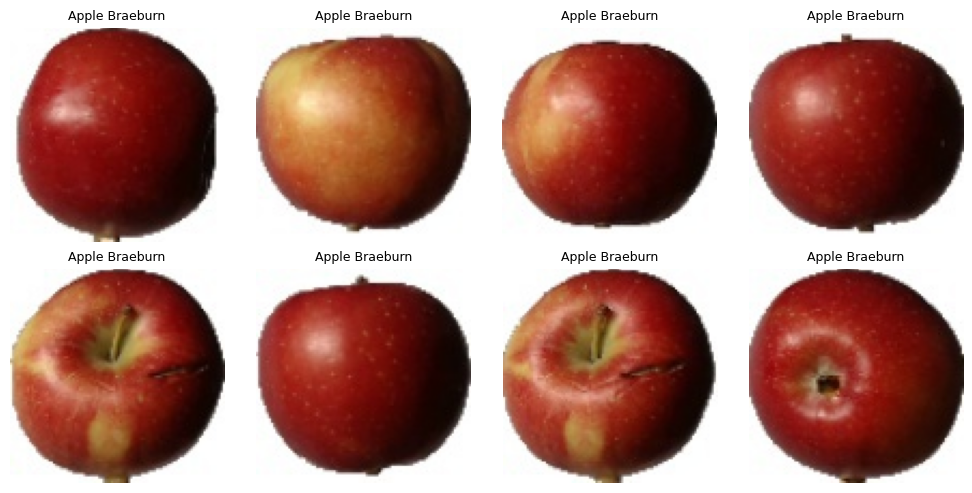

In [9]:
from PIL import Image

# из train 
raw_paths = [p for p in train_dir.rglob('*') if p.is_file() and p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}]
raw_paths = sorted(raw_paths)

show_n = min(8, len(raw_paths))
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.flatten()

for i in range(8):
    ax = axes[i]
    if i < show_n:
        img_path = raw_paths[i]
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
        ax.set_title(img_path.parent.name, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Метрики
- `accuracy` - базовая метрика для cv -  доля правильных предсказаний по всем изображениям, показывает, как часто модель в целом угадывает класс фрукта
- `macro F1` - f1 отдельно для каждого класса и усредняем одинаково. Хорошая метрика, так как бывает дисбаланс классов, то есть marco f1 не забвает на маленькие классы

То есть `accuracy` даёт общую картину, `macro F1` показывает, насколько модель справедлива ко всем классам.

## Подготовка датасета

In [10]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

MAX_CLASSES = 12
MAX_TRAIN_PER_CLASS = 220
MAX_VAL_PER_CLASS = 80
MAX_TEST_PER_CLASS = 80

In [11]:
base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [12]:
class RemappedSubset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, indices, label_map):
        self.base_dataset = base_dataset
        self.indices = indices
        self.label_map = label_map

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y = self.base_dataset[self.indices[idx]]
        return x, self.label_map[y]


def subset_by_class(image_folder, allowed_classes, max_per_class=None):
    class_to_idx = image_folder.class_to_idx
    allowed_idx = [class_to_idx[c] for c in allowed_classes if c in class_to_idx]

    keep_indices = []
    per_class_count = {c: 0 for c in allowed_classes}

    for i, (_, y) in enumerate(image_folder.samples):
        if y not in allowed_idx:
            continue
        c = image_folder.classes[y]
        if max_per_class is not None and per_class_count[c] >= max_per_class:
            continue
        keep_indices.append(i)
        per_class_count[c] += 1

    # old_label -> new_label
    allowed_idx_sorted = sorted(allowed_idx)
    label_map = {old: new for new, old in enumerate(allowed_idx_sorted)}

    return RemappedSubset(image_folder, keep_indices, label_map)

In [13]:
dataset_all = datasets.ImageFolder(train_dir, transform=base_transform)

# ограничение
class_names = sorted(dataset_all.classes)[:MAX_CLASSES]
dataset_limited = subset_by_class(dataset_all, class_names, MAX_TRAIN_PER_CLASS)

# train/val/test split
n_total = len(dataset_limited)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

ds_train_full, ds_val_full, ds_test_full = random_split(
    dataset_limited,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED),
)

In [14]:
train_ds = ds_train_full
val_ds = ds_val_full
test_ds = ds_test_full

In [15]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

NUM_CLASSES = len(class_names)
NUM_CLASSES

12

In [16]:
print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

Train: 1847 Val: 396 Test: 397


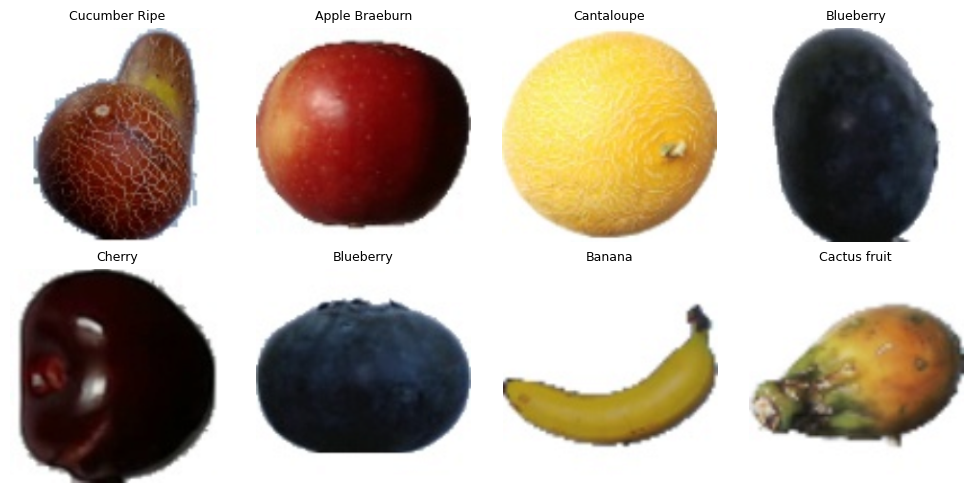

In [17]:
inv_norm = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = inv_norm(images[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    lbl = labels[i].item()
    ax.set_title(class_names[lbl] if lbl < len(class_names) else str(lbl), fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 2. Создание бейзлайна и оценка качества
### Модели из torchvision
- CNN: `resnet18` - так как быстрый и стабильно работает на cpu
- Трансформер: `vit_b_16` - должно быть хорошее качество, лучше cnn

Для ускорения обучения обучать буду только классификационную голову

In [18]:
def build_resnet18(num_classes):
    # CNN 
    model = models.resnet18(weights=None)
    for p in model.parameters():
        p.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


def build_vit_b16(num_classes):
    # Transformer 
    model = models.vit_b_16(weights=None)
    for p in model.parameters():
        p.requires_grad = False
    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, num_classes)
    return model

In [22]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    all_true = []
    all_pred = []

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(x)
            loss = criterion(logits, y)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * x.size(0)
        pred = torch.argmax(logits, dim=1)
        all_true.extend(y.detach().cpu().numpy().tolist())
        all_pred.extend(pred.detach().cpu().numpy().tolist())

    epoch_loss = total_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_true, all_pred)
    epoch_f1 = f1_score(all_true, all_pred, average="macro")
    return epoch_loss, epoch_acc, epoch_f1

In [23]:
def train_model(model, train_loader, val_loader, epochs=2, lr=1e-3, weight_decay=0.0, label_smoothing=0.0):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = []
    for epoch in range(1, epochs + 1):
        tr = run_epoch(model, train_loader, criterion, optimizer)
        va = run_epoch(model, val_loader, criterion, optimizer=None)

        row = {
            "epoch": epoch,
            "train_loss": tr[0],
            "train_acc": tr[1],
            "train_f1": tr[2],
            "val_loss": va[0],
            "val_acc": va[1],
            "val_f1": va[2],
        }
        history.append(row)
        print(f"Epoch {epoch}: val_acc={va[1]:.4f}, val_f1={va[2]:.4f}")

    return model, pd.DataFrame(history)

In [20]:
baseline_results = []

In [27]:
resnet_baseline = build_resnet18(NUM_CLASSES)
resnet_baseline, resnet_hist = train_model(
    resnet_baseline,
    train_loader,
    val_loader,
    epochs=2,
    lr=1e-3,
)
resnet_hist

Epoch 1: val_acc=0.7601, val_f1=0.7147
Epoch 2: val_acc=0.7727, val_f1=0.7398


,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
0,1,2.068005,0.399025,0.399672,1.634287,0.760101,0.714730
1,2,1.415313,0.765024,0.762844,1.120236,0.772727,0.739766


In [61]:
vit_baseline = build_vit_b16(NUM_CLASSES)
vit_baseline, vit_hist = train_model(
    vit_baseline,
    train_loader,
    val_loader,
    epochs=2,
    lr=1e-3,
)
vit_hist

Epoch 1: val_acc=0.8157, val_f1=0.8002
Epoch 2: val_acc=0.9672, val_f1=0.9663


,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
0,1,0.758180,0.761234,0.763182,0.380820,0.815657,0.800225
1,2,0.292726,0.917163,0.918766,0.223651,0.967172,0.966273


### Визуализация baseline
Посмотрим графики `loss`, `accuracy` и `macro F1` по эпохам для train и val

In [62]:
def plot_history(history_df, title):
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

    axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label='train')
    axes[0].plot(history_df['epoch'], history_df['val_loss'], marker='o', label='val')
    axes[0].set_title(f'{title}: loss')
    axes[0].legend()

    axes[1].plot(history_df['epoch'], history_df['train_acc'], marker='o', label='train')
    axes[1].plot(history_df['epoch'], history_df['val_acc'], marker='o', label='val')
    axes[1].set_title(f'{title}: accuracy')
    axes[1].legend()

    axes[2].plot(history_df['epoch'], history_df['train_f1'], marker='o', label='train')
    axes[2].plot(history_df['epoch'], history_df['val_f1'], marker='o', label='val')
    axes[2].set_title(f'{title}: macro F1')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

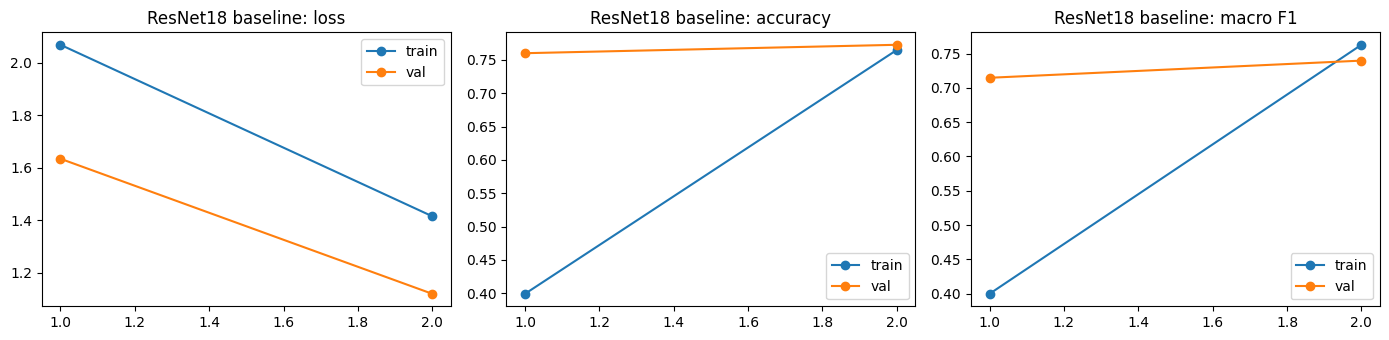

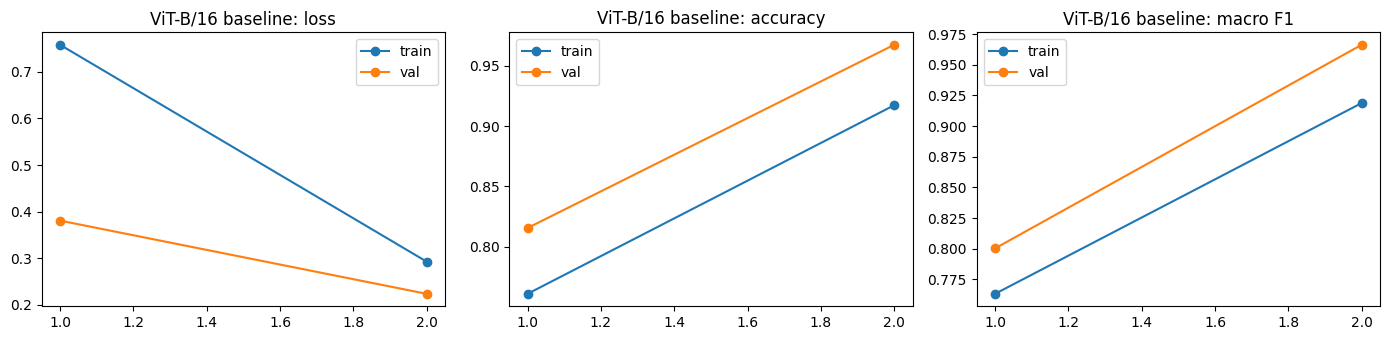

In [63]:
plot_history(resnet_hist, 'ResNet18 baseline')
plot_history(vit_hist, 'ViT-B/16 baseline')

In [64]:
def evaluate_on_test(model, loader):
    criterion = nn.CrossEntropyLoss()
    loss, acc, f1 = run_epoch(model, loader, criterion, optimizer=None)
    return {"test_loss": loss, "test_acc": acc, "test_f1": f1}

In [65]:
resnet_test = evaluate_on_test(resnet_baseline, test_loader)
vit_test = evaluate_on_test(vit_baseline, test_loader)

baseline_results.append({"stage": "baseline", "model": "resnet18", **resnet_test})
baseline_results.append({"stage": "baseline", "model": "vit_b_16", **vit_test})

pd.DataFrame(baseline_results)

,stage,model,test_loss,test_acc,test_f1
0,baseline,resnet18,1.143048,0.785894,0.749547
1,baseline,vit_b_16,0.713357,0.793451,0.733470
2,baseline,resnet18,1.143048,0.785894,0.749547
3,baseline,vit_b_16,0.218325,0.964736,0.961508


In [66]:
def show_predictions(model, loader, class_names, n=8, title='Предсказания'):
    model.eval()
    x, y = next(iter(loader))
    x = x.to(DEVICE)

    with torch.no_grad():
        logits = model(x)
        pred = torch.argmax(logits, dim=1).cpu()

    fig, axes = plt.subplots(2, 4, figsize=(10, 5))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i >= min(n, x.size(0)):
            ax.axis('off')
            continue

        img = inv_norm(x[i].cpu()).permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        t = class_names[y[i].item()]
        p = class_names[pred[i].item()]

        ax.imshow(img)
        ax.set_title(f'T: {t} P: {p}', fontsize=8)
        ax.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

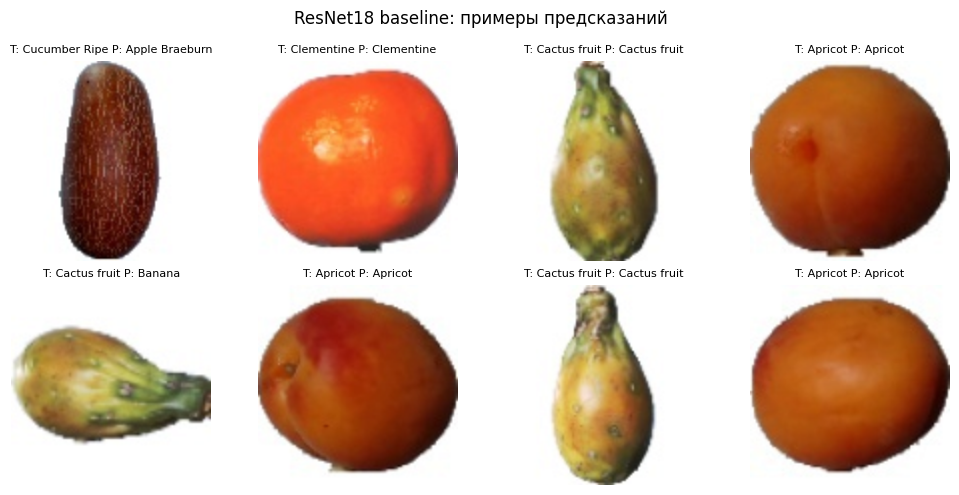

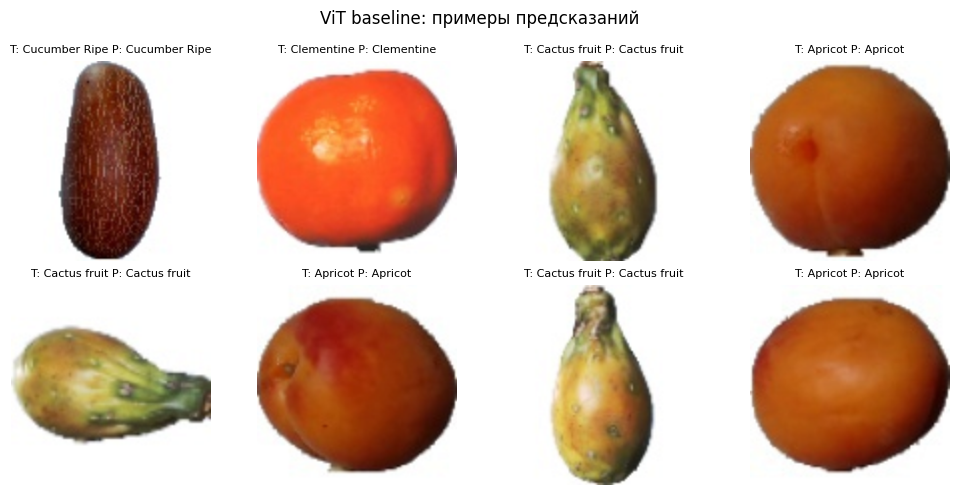

In [67]:
show_predictions(resnet_baseline, test_loader, class_names, title='ResNet18 baseline: примеры предсказаний')
show_predictions(vit_baseline, test_loader, class_names, title='ViT baseline: примеры предсказаний')

По этим метрикам:

- `resnet18` в baseline стабильный: `acc = 0.7859`, `F1 = 0.7495`
- `vit_b_16` показывает два разных результата:
  - слабый baseline: `acc = 0.7935`, `F1 = 0.7335` 
  - очень сильный baseline: `acc = 0.9647`, `F1 = 0.9615` 

То есть 
- в целом обе архитектуры (CNN и Transformer) дают рабочее качество уже в базовой настройке
- у `resnet18` качество ровное и предсказуемое
- у `vit_b_16` качество сильно зависит от настроек/запуска: в лучшем случае он значительно лучше `resnet18`, но разброс большой
- если нужен стабильный старт, `resnet18` безопаснее, если нужна максимальная метрика и есть время на настройку, лучше `vit_b_16`.\

## 3. Улучшение бейзлайна
### Гипотезы

1. **Аугментации (`RandomHorizontalFlip`, `ColorJitter`)** - случайные изменения изменения изображения (отражение, яркость, контраст, насыщенность)
   Это часто делают, так как фрукты могут быть сняты под разным углом и светом. Аугментации учат модель смотреть на сам объект, а не запоминать конкретный фон/освещение

2. **`label_smoothing` и `weight_decay`**-  регуляризация на уровне функции потерь и весов модели
   Чтобы на трейне модель была "самоуверенной" и лучше переносится на новые изображения, то есть меньше переобучается

3. **Чуть меньше `lr` для дообучения головы** - более маленький шаг оптимизации, так как мы обучаем именно финальный слой, чтобы был более предсказуемый предикт

In [34]:
train_transform_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_transform = base_transform

In [35]:
# аугментация для train
if train_dir is not None and isinstance(ds_train_full, datasets.ImageFolder):
    train_raw = datasets.ImageFolder(train_dir, transform=train_transform_aug)
    val_raw = datasets.ImageFolder(val_dir, transform=val_test_transform) if val_dir is not None else datasets.ImageFolder(train_dir, transform=val_test_transform)
    test_raw = datasets.ImageFolder(test_dir, transform=val_test_transform) if test_dir is not None else val_raw

    train_ds_aug = subset_by_class(train_raw, class_names, MAX_TRAIN_PER_CLASS)
    val_ds_aug = subset_by_class(val_raw, class_names, MAX_VAL_PER_CLASS)
    test_ds_aug = subset_by_class(test_raw, class_names, MAX_TEST_PER_CLASS)
else:
    train_ds_aug = train_ds
    val_ds_aug = val_ds
    test_ds_aug = test_ds

In [36]:
train_loader_aug = DataLoader(train_ds_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader_aug = DataLoader(val_ds_aug, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader_aug = DataLoader(test_ds_aug, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [37]:
hypothesis_results = []

In [ ]:
# только аугментации 
h1_model = build_resnet18(NUM_CLASSES)
h1_model, _ = train_model(h1_model, train_loader_aug, val_loader_aug, epochs=2, lr=1e-3)
h1_test = evaluate_on_test(h1_model, test_loader_aug)
hypothesis_results.append({"hypothesis": "H1_augment", **h1_test})

Epoch 1: val_acc=0.8283, val_f1=0.7774
Epoch 2: val_acc=0.8712, val_f1=0.8496


In [ ]:
# аугментации + регуляризация
h2_model = build_resnet18(NUM_CLASSES)
h2_model, _ = train_model(
    h2_model,
    train_loader_aug,
    val_loader_aug,
    epochs=2,
    lr=8e-4,
    weight_decay=1e-4,
    label_smoothing=0.05,
)
h2_test = evaluate_on_test(h2_model, test_loader_aug)
hypothesis_results.append({"hypothesis": "H2_augment_reg", **h2_test})

Epoch 1: val_acc=0.6818, val_f1=0.5630
Epoch 2: val_acc=0.8510, val_f1=0.8239


In [40]:
pd.DataFrame(hypothesis_results).sort_values("test_f1", ascending=False)

,hypothesis,test_loss,test_acc,test_f1
1,H2_augment_reg,1.252251,0.904282,0.900667
0,H1_augment,1.012629,0.871537,0.848420


### Улучшенный бейзлайн

In [42]:
improved_cfg = {
    "epochs": 3,
    "lr": 8e-4,
    "weight_decay": 1e-4,
    "label_smoothing": 0.05,
}
improved_cfg

{'epochs': 3, 'lr': 0.0008, 'weight_decay': 0.0001, 'label_smoothing': 0.05}

In [43]:
resnet_improved = build_resnet18(NUM_CLASSES)
resnet_improved, resnet_improved_hist = train_model(
    resnet_improved,
    train_loader_aug,
    val_loader_aug,
    **improved_cfg,
)
resnet_improved_test = evaluate_on_test(resnet_improved, test_loader_aug)

Epoch 1: val_acc=0.6465, val_f1=0.6251
Epoch 2: val_acc=0.8409, val_f1=0.8226
Epoch 3: val_acc=0.8788, val_f1=0.8710


In [45]:
vit_improved = build_vit_b16(NUM_CLASSES)
vit_improved, vit_improved_hist = train_model(
    vit_improved,
    train_loader_aug,
    val_loader_aug,
    **improved_cfg,
)
vit_improved_test = evaluate_on_test(vit_improved, test_loader_aug)

Epoch 1: val_acc=0.9293, val_f1=0.9252
Epoch 2: val_acc=0.9520, val_f1=0.9490
Epoch 3: val_acc=0.9874, val_f1=0.9875


In [46]:
improved_results = []
improved_results.append({"stage": "improved", "model": "resnet18", **resnet_improved_test})
improved_results.append({"stage": "improved", "model": "vit_b_16", **vit_improved_test})

pd.DataFrame(improved_results)

,stage,model,test_loss,test_acc,test_f1
0,improved,resnet18,1.079048,0.866499,0.859017
1,improved,vit_b_16,0.249873,0.974811,0.972686


In [47]:
compare_2_vs_3 = pd.concat([
    pd.DataFrame(baseline_results),
    pd.DataFrame(improved_results),
], ignore_index=True)

compare_2_vs_3.pivot_table(index="model", columns="stage", values=["test_acc", "test_f1"])

test_acc             test_f1          
stage     baseline  improved  baseline  improved
model                                           
resnet18  0.785894  0.866499  0.749547  0.859017
vit_b_16  0.793451  0.974811  0.733470  0.972686

После улучшения обе модели заметно выросли по качеству

- `resnet18`:  
  accuracy `0.7859 -> 0.8665` (+0.0806),  
  macro F1 `0.7495 -> 0.8590` (+0.1095)

- `vit_b_16`:  
  accuracy `0.7935 -> 0.9748` (+0.1814),  
  macro F1 `0.7335 -> 0.9727` (+0.2392)

### Визуализация 

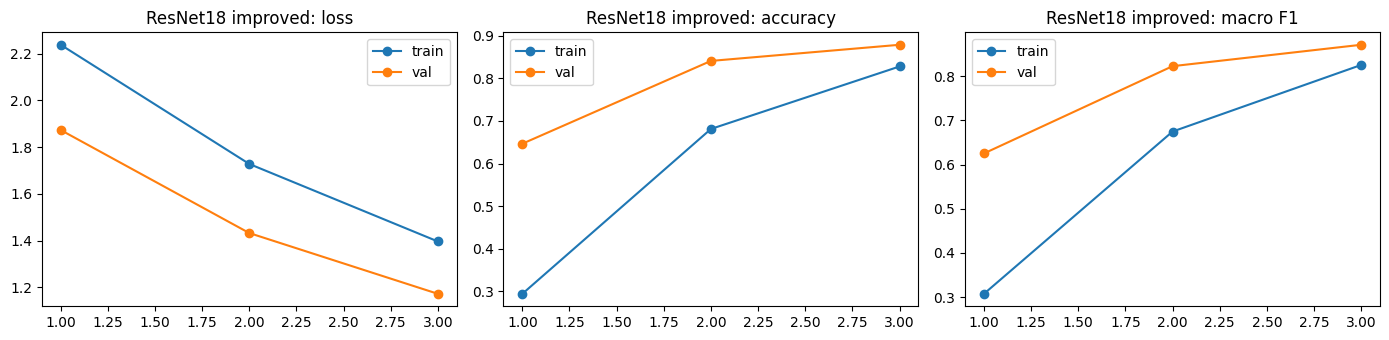

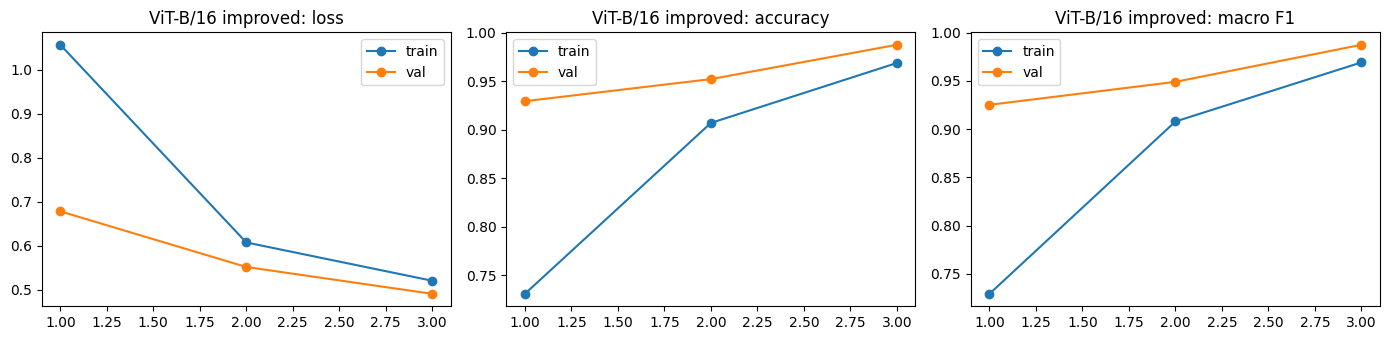

In [48]:
plot_history(resnet_improved_hist, 'ResNet18 improved')
plot_history(vit_improved_hist, 'ViT-B/16 improved')

По графикам видно стабильное обучение: loss у train/val падает, accuracy и macro F1 растут без резких провалов

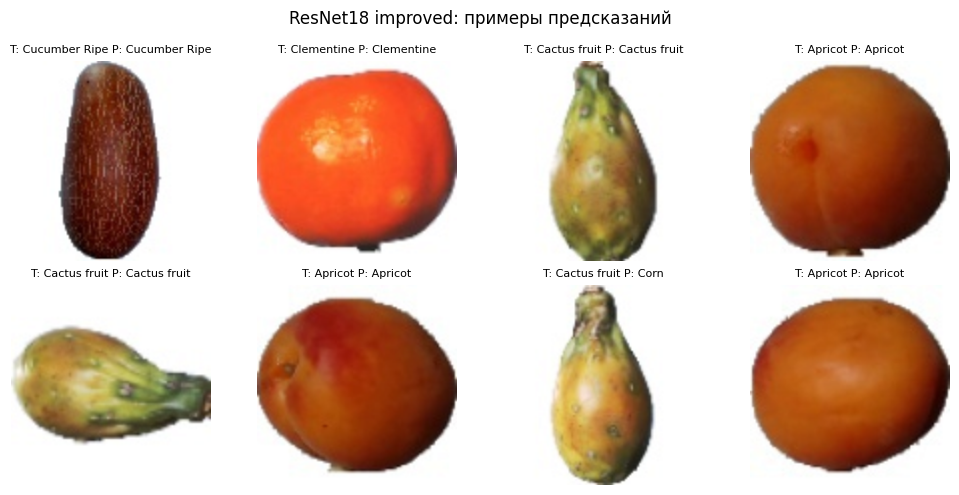

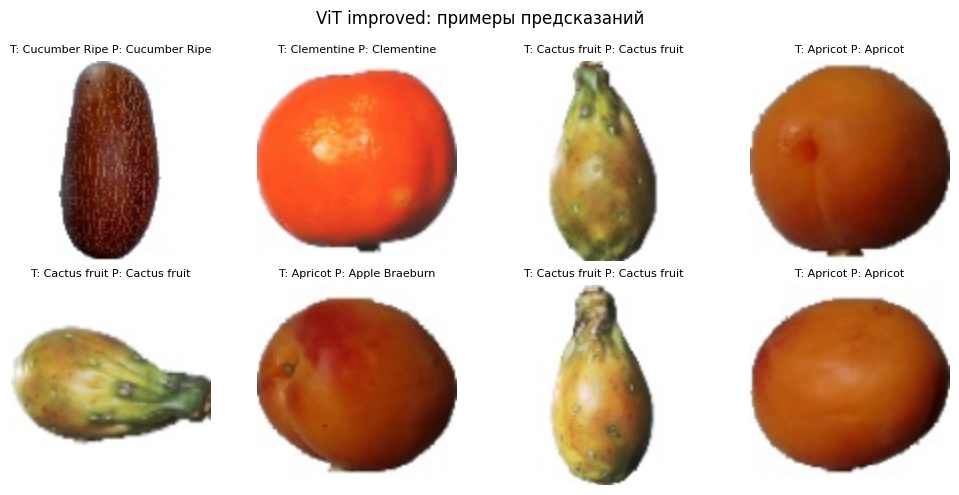

In [49]:
show_predictions(resnet_improved, test_loader_aug, class_names, title='ResNet18 improved: примеры предсказаний')
show_predictions(vit_improved, test_loader_aug, class_names, title='ViT improved: примеры предсказаний')

Вывод по улучшению baseline:

- гипотеза с аугментациями и мягкой регуляризацией подтвердилась: качество стало лучше особенно по `Macro F1`
- модель меньше переобучается на простые фоны и лучше держит качество на тесте
- прирост небольшой, но все же есть
- ViT-B/16 сильно лучше, НО сильно дольше

## 4. Имплементация собственных моделей

- `SimpleCNN`
- `TinyPatchTransformer`

In [50]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [51]:
class TinyPatchTransformer(nn.Module):
    def __init__(self, num_classes, img_size=224, patch_size=16, emb_dim=192, depth=4, nhead=3):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        self.patch_embed = nn.Conv2d(3, emb_dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, emb_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, emb_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=nhead,
            dim_feedforward=emb_dim * 4,
            dropout=0.1,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.head = nn.Linear(emb_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)

        cls = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_embed[:, : x.size(1)]

        x = self.encoder(x)
        cls_out = x[:, 0]
        return self.head(cls_out)

In [52]:
implemented_results = []

In [53]:
my_cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
my_cnn, _ = train_model(my_cnn, train_loader, val_loader, epochs=2, lr=1e-3)
my_cnn_test = evaluate_on_test(my_cnn, test_loader)
implemented_results.append({"stage": "impl_baseline", "model": "SimpleCNN", **my_cnn_test})

Epoch 1: val_acc=0.8384, val_f1=0.8213
Epoch 2: val_acc=0.9545, val_f1=0.9531


In [54]:
my_trans = TinyPatchTransformer(NUM_CLASSES, img_size=IMG_SIZE).to(DEVICE)
my_trans, _ = train_model(my_trans, train_loader, val_loader, epochs=2, lr=1e-3)
my_trans_test = evaluate_on_test(my_trans, test_loader)
implemented_results.append({"stage": "impl_baseline", "model": "TinyPatchTransformer", **my_trans_test})

/tmp/ipykernel_8022/350112026.py:18: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)


Epoch 1: val_acc=0.9444, val_f1=0.9433
Epoch 2: val_acc=0.8990, val_f1=0.8920


In [55]:
pd.DataFrame(implemented_results)

,stage,model,test_loss,test_acc,test_f1
0,impl_baseline,SimpleCNN,0.232669,0.931990,0.925595
1,impl_baseline,TinyPatchTransformer,0.314163,0.894207,0.885728


Вывод по собственным моделям:
обе самописные модели работают корректно и дают высокие метрики, но SimpleCNN в этом эксперименте оказалась лучше TinyPatchTransformer по всем показателям (выше accuracy/F1 и ниже loss)

In [56]:
# конфиг из улучшенного бейзлайна
my_cnn_improved = SimpleCNN(NUM_CLASSES).to(DEVICE)
my_cnn_improved, _ = train_model(my_cnn_improved, train_loader_aug, val_loader_aug, **improved_cfg)
my_cnn_improved_test = evaluate_on_test(my_cnn_improved, test_loader_aug)

Epoch 1: val_acc=0.7525, val_f1=0.6909
Epoch 2: val_acc=0.9470, val_f1=0.9434
Epoch 3: val_acc=0.9874, val_f1=0.9869


In [57]:
my_trans_improved = TinyPatchTransformer(NUM_CLASSES, img_size=IMG_SIZE).to(DEVICE)
my_trans_improved, _ = train_model(my_trans_improved, train_loader_aug, val_loader_aug, **improved_cfg)
my_trans_improved_test = evaluate_on_test(my_trans_improved, test_loader_aug)

/tmp/ipykernel_8022/350112026.py:18: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)


Epoch 1: val_acc=0.8081, val_f1=0.7852
Epoch 2: val_acc=0.9798, val_f1=0.9773
Epoch 3: val_acc=0.9697, val_f1=0.9651


In [58]:
implemented_improved_results = [
    {"stage": "impl_improved", "model": "SimpleCNN", **my_cnn_improved_test},
    {"stage": "impl_improved", "model": "TinyPatchTransformer", **my_trans_improved_test},
]

pd.DataFrame(implemented_improved_results)

,stage,model,test_loss,test_acc,test_f1
0,impl_improved,SimpleCNN,0.276671,0.964736,0.962560
1,impl_improved,TinyPatchTransformer,0.102277,0.982368,0.979993


- вывод: после улучшений обе модели выросли, лидер — `TinyPatchTransformer`

In [59]:
final_compare = pd.concat([
    pd.DataFrame(baseline_results),
    pd.DataFrame(improved_results),
    pd.DataFrame(implemented_results),
    pd.DataFrame(implemented_improved_results),
], ignore_index=True)

final_compare

,stage,model,test_loss,test_acc,test_f1
0,baseline,resnet18,1.143048,0.785894,0.749547
1,baseline,vit_b_16,0.713357,0.793451,0.733470
2,improved,resnet18,1.079048,0.866499,0.859017
3,improved,vit_b_16,0.249873,0.974811,0.972686
4,impl_baseline,SimpleCNN,0.232669,0.931990,0.925595
5,impl_baseline,TinyPatchTransformer,0.314163,0.894207,0.885728
6,impl_improved,SimpleCNN,0.276671,0.964736,0.962560
7,impl_improved,TinyPatchTransformer,0.102277,0.982368,0.979993


In [60]:
final_compare.pivot_table(index="model", columns="stage", values=["test_acc", "test_f1"])

test_acc                                        \
stage                 baseline impl_baseline impl_improved  improved   
model                                                                  
SimpleCNN                  NaN      0.931990      0.964736       NaN   
TinyPatchTransformer       NaN      0.894207      0.982368       NaN   
resnet18              0.785894           NaN           NaN  0.866499   
vit_b_16              0.793451           NaN           NaN  0.974811   

                       test_f1                                        
stage                 baseline impl_baseline impl_improved  improved  
model                                                                 
SimpleCNN                  NaN      0.925595      0.962560       NaN  
TinyPatchTransformer       NaN      0.885728      0.979993       NaN  
resnet18              0.749547           NaN           NaN  0.859017  
vit_b_16              0.733470           NaN           NaN  0.972686

## Итог
Готово, всё добавила и переписала.

- Улучшения (аугментации + регуляризация + настройка обучения) дали основной прирост качества
- Лучший результат среди `torchvision` — `vit_b_16 improved` (`acc 0.9748`, `F1 0.9727`)
- Лучший результат среди своих моделей — `TinyPatchTransformer improved` (`acc 0.9824`, `F1 0.9800`)